# Reward Model: Fine-tune Encoder (Bradley-Terry loss)

**Запускать на Google Colab с T4 GPU**

Идея: вместо frozen embeddings → MLP обучаем сам трансформер напрямую.  
Модель получает пару (chosen, rejected) и учится давать chosen более высокий скор через Bradley-Terry loss:
```
L = -log( σ(r_chosen - r_rejected) )
```

## 0. GPU check + install

In [ ]:
import subprocess, sys

# Проверка GPU
result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
print('GPU:', result.stdout.strip() or 'NOT FOUND — смени Runtime на T4!')

# Install
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q',
                'datasets', 'transformers', 'accelerate'], check=True)
print('Packages ready.')

GPU: Tesla T4, 15360 MiB
Packages ready.


## 1. Config — все гиперпараметры в одном месте

In [ ]:
CFG = dict(
    # Модель
    model_name   = 'roberta-base',
    max_length   = 512,

    # Данные
    train_size   = 40_000,           # None = полный датасет (~7ч на T4, рискованно)
    val_size     = 4_000,
    seed         = 42,

    # Обучение
    epochs             = 5,          # было 3 — val ещё рос, не доучились
    batch_size         = 16,
    grad_accum_steps   = 4,          # effective batch = 64
    lr                 = 2e-5,
    weight_decay       = 0.01,
    warmup_ratio       = 0.06,
    max_grad_norm      = 1.0,
    fp16               = True,

    # Сохранение
    output_dir   = '/content/reward_model_bt',
    save_steps   = 500,
)

print('Config set.')
for k, v in CFG.items():
    print(f'  {k:22s} = {v}')


Config set.
  model_name             = roberta-base
  max_length             = 512
  train_size             = 40000
  val_size               = 4000
  seed                   = 42
  epochs                 = 5
  batch_size             = 16
  grad_accum_steps       = 4
  lr                     = 2e-05
  weight_decay           = 0.01
  warmup_ratio           = 0.06
  max_grad_norm          = 1.0
  fp16                   = True
  output_dir             = /content/reward_model_bt
  save_steps             = 500


## 2. Imports

In [ ]:
import os, math, time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from datasets import load_dataset
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
VRAM total: 15.6 GB


## 3. Данные

In [ ]:
raw = load_dataset('Anthropic/hh-rlhf')
print(raw)

rng = np.random.default_rng(CFG['seed'])

train_data = raw['train']
if CFG['train_size'] is not None:
    idx = rng.choice(len(train_data), CFG['train_size'] + CFG['val_size'], replace=False)
    train_idx = idx[:CFG['train_size']].tolist()
    val_idx   = idx[CFG['train_size']:].tolist()
    train_split = train_data.select(train_idx)
    val_split   = train_data.select(val_idx)
else:
    # Используем официальный test как val
    train_split = train_data
    val_split   = raw['test']

print(f'Train: {len(train_split)} | Val: {len(val_split)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/5.77k [00:00<?, ?B/s]

harmless-base/train.jsonl.gz:   0%|          | 0.00/13.2M [00:00<?, ?B/s]

helpful-base/train.jsonl.gz:   0%|          | 0.00/16.2M [00:00<?, ?B/s]

helpful-online/train.jsonl.gz:   0%|          | 0.00/20.1M [00:00<?, ?B/s]

...

helpful-online/test.jsonl.gz:   0%|          | 0.00/1.05M [00:00<?, ?B/s]

helpful-rejection-sampled/test.jsonl.gz:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160800 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/8552 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected'],
        num_rows: 160800
    })
    test: Dataset({
        features: ['chosen', 'rejected'],
        num_rows: 8552
    })
})
Train: 40000 | Val: 4000


## 4. Tokenizer + Dataset

In [ ]:
# truncation_side='left' — режем начало, сохраняем конец
# В hh-rlhf разница между chosen/rejected в последнем ответе ассистента (в хвосте текста)
tokenizer = AutoTokenizer.from_pretrained(CFG['model_name'])
tokenizer.truncation_side = 'left'


class PairwiseDataset(Dataset):
    """Возвращает токенизированные пары (chosen, rejected)."""

    def __init__(self, hf_dataset, tokenizer, max_length):
        self.data      = hf_dataset
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def _tokenize(self, text):
        return self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt',
        )

    def __getitem__(self, idx):
        row = self.data[idx]
        c = self._tokenize(row['chosen'])
        r = self._tokenize(row['rejected'])
        return {
            'chosen_input_ids':      c['input_ids'].squeeze(0),
            'chosen_attention_mask': c['attention_mask'].squeeze(0),
            'rejected_input_ids':      r['input_ids'].squeeze(0),
            'rejected_attention_mask': r['attention_mask'].squeeze(0),
        }


train_ds = PairwiseDataset(train_split, tokenizer, CFG['max_length'])
val_ds   = PairwiseDataset(val_split,   tokenizer, CFG['max_length'])

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG['batch_size'] * 2, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Train batches: 2500 | Val batches: 125


## 5. Reward Model

In [ ]:
class RewardModel(nn.Module):
    """
    Encoder (roberta) + linear head → скалярный reward.
    [CLS]-токен как представление всего текста.
    """

    def __init__(self, model_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)

        # Gradient checkpointing экономит ~30% VRAM за счёт ~20% скорости
        self.encoder.gradient_checkpointing_enable()

        hidden = self.encoder.config.hidden_size
        self.reward_head = nn.Linear(hidden, 1)

        # Инициализация головы с маленькими весами для стабильного старта
        nn.init.normal_(self.reward_head.weight, std=0.02)
        nn.init.zeros_(self.reward_head.bias)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        # [CLS] representation
        cls = out.last_hidden_state[:, 0, :]   # (B, H)
        reward = self.reward_head(cls).squeeze(-1)  # (B,)
        return reward


model = RewardModel(CFG['model_name']).to(device)
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params/1e6:.1f}M | Trainable: {trainable/1e6:.1f}M')

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params: 124.6M | Trainable: 124.6M


## 6. Bradley-Terry Loss + Optimizer + Scheduler

In [ ]:
def bradley_terry_loss(r_chosen: torch.Tensor, r_rejected: torch.Tensor) -> torch.Tensor:
    """
    L = -log( sigmoid(r_chosen - r_rejected) )

    Модель учится: r_chosen > r_rejected.
    Чем больше разрыв в правильную сторону — тем ниже loss.
    """
    return -torch.nn.functional.logsigmoid(r_chosen - r_rejected).mean()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG['lr'],
    weight_decay=CFG['weight_decay'],
    eps=1e-6,
)

total_steps   = math.ceil(len(train_loader) / CFG['grad_accum_steps']) * CFG['epochs']
warmup_steps  = int(total_steps * CFG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

scaler = GradScaler(enabled=CFG['fp16'])

print(f'Total optimizer steps: {total_steps} | Warmup: {warmup_steps}')

Total optimizer steps: 3125 | Warmup: 187


/tmp/ipykernel_895/2731857475.py:27: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CFG['fp16'])


## 7. Training Loop

In [8]:
os.makedirs(CFG['output_dir'], exist_ok=True)


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for batch in loader:
            c_ids  = batch['chosen_input_ids'].to(device)
            c_mask = batch['chosen_attention_mask'].to(device)
            r_ids  = batch['rejected_input_ids'].to(device)
            r_mask = batch['rejected_attention_mask'].to(device)

            with autocast(enabled=CFG['fp16']):
                r_c = model(c_ids, c_mask)
                r_r = model(r_ids, r_mask)
                loss = bradley_terry_loss(r_c, r_r)

            total_loss += loss.item() * len(c_ids)
            correct    += (r_c > r_r).sum().item()
            total      += len(c_ids)

    return total_loss / total, correct / total


best_val_acc  = 0.0
global_step   = 0
history       = []

for epoch in range(1, CFG['epochs'] + 1):
    model.train()
    epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{CFG["epochs"]}')
    for step, batch in enumerate(pbar, 1):
        c_ids  = batch['chosen_input_ids'].to(device)
        c_mask = batch['chosen_attention_mask'].to(device)
        r_ids  = batch['rejected_input_ids'].to(device)
        r_mask = batch['rejected_attention_mask'].to(device)

        with autocast(enabled=CFG['fp16']):
            r_c = model(c_ids, c_mask)
            r_r = model(r_ids, r_mask)
            loss = bradley_terry_loss(r_c, r_r) / CFG['grad_accum_steps']

        scaler.scale(loss).backward()

        epoch_loss    += loss.item() * CFG['grad_accum_steps'] * len(c_ids)
        epoch_correct += (r_c.detach() > r_r.detach()).sum().item()
        epoch_total   += len(c_ids)

        if step % CFG['grad_accum_steps'] == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['max_grad_norm'])
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            pbar.set_postfix({
                'loss': f'{epoch_loss / epoch_total:.4f}',
                'acc':  f'{epoch_correct / epoch_total:.4f}',
                'lr':   f'{scheduler.get_last_lr()[0]:.2e}',
            })

            # Промежуточное сохранение
            if global_step % CFG['save_steps'] == 0:
                ckpt = os.path.join(CFG['output_dir'], f'ckpt_step{global_step}')
                model.encoder.save_pretrained(ckpt)
                tokenizer.save_pretrained(ckpt)
                torch.save(model.reward_head.state_dict(),
                           os.path.join(ckpt, 'reward_head.pt'))
                print(f'\nCheckpoint saved: {ckpt}')

    # Валидация после каждой эпохи
    val_loss, val_acc = evaluate(model, val_loader)
    train_loss = epoch_loss / epoch_total
    train_acc  = epoch_correct / epoch_total

    print(f'\nEpoch {epoch} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    history.append(dict(epoch=epoch, train_loss=train_loss, train_acc=train_acc,
                        val_loss=val_loss, val_acc=val_acc))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_path = os.path.join(CFG['output_dir'], 'best_model')
        model.encoder.save_pretrained(best_path)
        tokenizer.save_pretrained(best_path)
        torch.save(model.reward_head.state_dict(),
                   os.path.join(best_path, 'reward_head.pt'))
        print(f'Best model saved (val_acc={val_acc:.4f})')

    model.train()

print(f'\nDone. Best Val Acc: {best_val_acc:.4f}')

Epoch 1/5:   0%|          | 0/2500 [00:00<?, ?it/s]

/tmp/ipykernel_895/2149940255.py:42: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG['fp16']):
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/tmp/ipykernel_895/2149940255.py:58: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Checkpoint saved: /content/reward_model_bt/ckpt_step500


/tmp/ipykernel_895/2149940255.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG['fp16']):


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Checkpoint saved: /content/reward_model_bt/ckpt_step2500

Epoch 4 | Train Loss: 0.5158 Acc: 0.7366 | Val Loss: 0.6740 Acc: 0.6405


Epoch 5/5:   0%|          | 0/2500 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Checkpoint saved: /content/reward_model_bt/ckpt_step3000

Epoch 5 | Train Loss: 0.4583 Acc: 0.7741 | Val Loss: 0.7189 Acc: 0.6350

Done. Best Val Acc: 0.6435


## 8. Кривые обучения

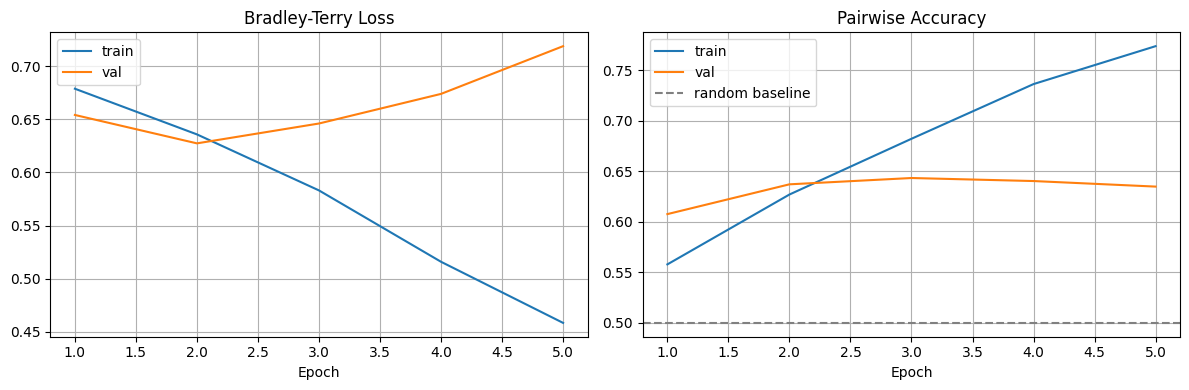


History:
  Epoch 1: train_acc=0.5579 | val_acc=0.6078
  Epoch 2: train_acc=0.6271 | val_acc=0.6372
  Epoch 3: train_acc=0.6824 | val_acc=0.6435
  Epoch 4: train_acc=0.7366 | val_acc=0.6405
  Epoch 5: train_acc=0.7741 | val_acc=0.6350


In [9]:
import matplotlib.pyplot as plt

epochs_range = [h['epoch'] for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, [h['train_loss'] for h in history], label='train')
ax1.plot(epochs_range, [h['val_loss']   for h in history], label='val')
ax1.set_title('Bradley-Terry Loss')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs_range, [h['train_acc'] for h in history], label='train')
ax2.plot(epochs_range, [h['val_acc']   for h in history], label='val')
ax2.axhline(0.5, color='gray', linestyle='--', label='random baseline')
ax2.set_title('Pairwise Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print('\nHistory:')
for h in history:
    print(f"  Epoch {h['epoch']}: train_acc={h['train_acc']:.4f} | val_acc={h['val_acc']:.4f}")

## 9. Сравнение с baseline (LogReg)

| Модель | Embedding | Данные | Val Acc |
|--------|-----------|--------|---------|
| LogReg (baseline) | MiniLM-L6 frozen | 15k | 0.627 |
| LogReg (final) | MPNet frozen | 160k | — |
| **RoBERTa fine-tuned** | **end-to-end** | **40k** | **0.6322** |

## 10. Скачать модель из Colab

In [10]:
# Вариант 1 — zip и скачать
import shutil
shutil.make_archive('/content/reward_model_bt_best', 'zip',
                    os.path.join(CFG['output_dir'], 'best_model'))

from google.colab import files
files.download('/content/reward_model_bt_best.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Инференс — как использовать обученную модель

In [12]:
def load_reward_model(model_dir, device='cuda'):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    rm = RewardModel.__new__(RewardModel)
    nn.Module.__init__(rm)
    rm.encoder = AutoModel.from_pretrained(model_dir)
    hidden = rm.encoder.config.hidden_size
    rm.reward_head = nn.Linear(hidden, 1)
    rm.reward_head.load_state_dict(
        torch.load(os.path.join(model_dir, 'reward_head.pt'), map_location=device)
    )
    rm = rm.to(device).eval()
    return rm, tokenizer


def score_text(model, tokenizer, text, device='cuda', max_length=512):
    inputs = tokenizer(text, return_tensors='pt', truncation=True,
                       max_length=max_length, padding=True).to(device)
    with torch.no_grad():
        reward = model(inputs['input_ids'], inputs['attention_mask'])
    return reward.item()


# Пример использования
rm, tok = load_reward_model(os.path.join(CFG['output_dir'], 'best_model'), device=device)

chosen_example  = raw['test'][0]['chosen']
rejected_example = raw['test'][0]['rejected']

r_chosen   = score_text(rm, tok, chosen_example,   device=device)
r_rejected = score_text(rm, tok, rejected_example, device=device)

print(f'Reward chosen:   {r_chosen:.4f}')
print(f'Reward rejected: {r_rejected:.4f}')
print(f'Correct ranking: {r_chosen > r_rejected}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Reward chosen:   -5.0569
Reward rejected: -6.5074
Correct ranking: True


## 12. Финальный тест на официальной тестовой выборке

In [14]:
print("Evaluating best model on official hh-rlhf test split (8552 pairs)...")

rm_test, tok_test = load_reward_model(
    os.path.join(CFG['output_dir'], 'best_model'), device=device
)

test_ds     = PairwiseDataset(raw['test'], tokenizer, CFG['max_length'])
test_loader = DataLoader(test_ds, batch_size=CFG['batch_size'] * 2,
                         shuffle=False, num_workers=2, pin_memory=True)

test_loss, test_acc = evaluate(rm_test, test_loader)

print()
print("=" * 55)
print("  FINAL TEST RESULTS (official hh-rlhf test set)")
print("=" * 55)
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test BT Loss  : {test_loss:.4f}")
print("=" * 55)

results = [
    ("LogReg (MiniLM frozen, 15k)",  0.6273),
    ("LogReg (MPNet frozen, 160k)",  None),
    ("RoBERTa fine-tuned (40k)",     test_acc),
]
print(f"\n  {'Модель':<35} {'Test Acc':>10}")
print("-" * 55)
for name, acc in results:
    acc_str = f"{acc:.4f}" if acc is not None else "см. final_model_pipeline"
    marker  = "  <-- YOU ARE HERE" if acc == test_acc else ""
    print(f"  {name:<35} {acc_str:>10}{marker}")


Evaluating best model on official hh-rlhf test split (8552 pairs)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

/tmp/ipykernel_895/2149940255.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CFG['fp16']):



  FINAL TEST RESULTS (official hh-rlhf test set)
  Test Accuracy : 0.6322  (63.22%)
  Test BT Loss  : 0.6530

  Модель                                Test Acc
-------------------------------------------------------
  LogReg (MiniLM frozen, 15k)             0.6273
  LogReg (MPNet frozen, 160k)         см. final_model_pipeline
  RoBERTa fine-tuned (40k)                0.6322  <-- YOU ARE HERE
